# FNO Model Inference – Quick Review Notebook

Select a trained model, run inference on the held-out **test set**, and inspect the time-history / FFT output.

**Steps:**
1. Configure paths and select a model in *Cell 2*
2. (Optional) pick specific sample indices in *Cell 3*
3. Run all cells top-to-bottom

In [1]:
import os, sys, gc, re, pickle, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

sys.path.append(os.getcwd())
from neuralop.models import FNO
from module.dataprep_v2 import DynamicDataset

try:
    import scienceplots
    plt.style.use(['science', 'notebook'])
except ImportError:
    plt.style.use('seaborn-v0_8-darkgrid')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Using device: cuda


## 1 · Configuration

Set data paths and **choose the model** to evaluate.

In [2]:
# ── Data paths ────────────────────────────────────────────────────────────────
BASE_DATA_DIR = r'D:\BaiduNetdiskDownload\SesimicTransformerData'
GM_FILE       = os.path.join(BASE_DATA_DIR, 'MDOF', 'All_GMs', 'GMs_knet_3474_AF_57.h5')
BUILDING_DIR  = os.path.join(BASE_DATA_DIR, 'MDOF', 'knet-250', 'Data', 'fno')

OUTPUT_DIR    = Path('output/Paper_Experient')
FIG_EXPORT_DIR = Path('Fig_Paper_export')
FIG_EXPORT_DIR.mkdir(exist_ok=True)

# ── List available models (excludes E-* ablation runs) ───────────────────────
all_model_folders = sorted(
    [f for f in OUTPUT_DIR.iterdir()
     if f.is_dir() and not f.name.startswith('E-') and 'FNO' in f.name]
)

print('Available models:')
for i, f in enumerate(all_model_folders):
    print(f'  [{i}] {f.name}')

Available models:
  [0] Base-FNO_v1.0+_h64_m64_l4_e50_20251205_063911
  [1] Huge-FNO_v1.0+_h128_m1024_l12_e50_20251206_132248
  [2] Large-FNO_v1.0+_h64_m512_l8_e50_20251206_101922
  [3] Test-1-FNO_v1.0+_h64_m128_l4_e50_20251205_090131
  [4] Test-10-FNO_v1.0+_h64_m64_l12_e50_20251206_064433
  [5] Test-2-FNO_v1.0+_h64_m512_l4_e50_20251205_112502
  [6] Test-3-FNO_v1.0+_h64_m1024_l4_e50_20251205_134726
  [7] Test-4-FNO_v1.0+_h64_m1536_l4_e50_20251205_161228
  [8] Test-5-FNO_v1.0+_h16_m64_l4_e50_20251205_191306
  [9] Test-6-FNO_v1.0+_h32_m64_l4_e50_20251205_210306
  [10] Test-7-FNO_v1.0+_h128_m64_l4_e50_20251205_230156
  [11] Test-8-FNO_v1.0+_h64_m64_l2_e50_20251206_015346
  [12] Test-9-FNO_v1.0+_h64_m64_l8_e50_20251206_035109


In [3]:
# ── ★ SELECT MODEL HERE ──────────────────────────────────────────────────────
# Either pick by index from the list above, or set the full folder name.

MODEL_INDEX = 1          # <── change this index
# or set MODEL_NAME directly (overrides index when not None):
MODEL_NAME  = None       # e.g. 'Large-FNO_v1.0+_h64_m512_l8_e50_20251206_101922'

if MODEL_NAME:
    model_folder = OUTPUT_DIR / MODEL_NAME
else:
    model_folder = all_model_folders[MODEL_INDEX]

print(f'Selected model: {model_folder.name}')

Selected model: Huge-FNO_v1.0+_h128_m1024_l12_e50_20251206_132248


## 2 · Sample Selection

Load the test-set indices that were saved during training, then choose a few samples to visualise.

In [4]:
# ── Load test indices ─────────────────────────────────────────────────────────
pkl_path = model_folder / 'details' / 'dataset_indices.pkl'
with open(pkl_path, 'rb') as f:
    idx_dict = pickle.load(f)

test_indices = idx_dict.get('test', idx_dict.get('test_indices'))
print(f'Test-set size: {len(test_indices)} samples')

# ── Build dataset ─────────────────────────────────────────────────────────────
dataset   = DynamicDataset(
    gm_file_path       = GM_FILE,
    building_files_dir = BUILDING_DIR,
    gm_indices         = test_indices
)
print(f'Dataset length (relative indices): {len(dataset)}')

Test-set size: 19836 samples
Dataset length (relative indices): 19836


In [5]:
# ── ★ CHOOSE SAMPLES ─────────────────────────────────────────────────────────
# Set SPECIFIC_INDICES to a list of integer indices (within 0 … len(dataset)-1),
# or leave as None for a random pick.

SPECIFIC_INDICES = None          # e.g. [0, 100, 500, 1000]
N_RANDOM         = 3            # used when SPECIFIC_INDICES is None

if SPECIFIC_INDICES is not None:
    selected = [i for i in SPECIFIC_INDICES if i < len(dataset)]
else:
    selected = random.sample(range(len(dataset)), min(N_RANDOM, len(dataset)))

print(f'Selected sample indices: {selected}')

Selected sample indices: [7859, 82, 9893]


In [6]:
# ── Load samples from disk ────────────────────────────────────────────────────
samples = []
for idx in selected:
    data = dataset[idx]
    gm_data, blg_attr, acc_resp, blg_ds = data[:4]
    samples.append({
        'index'       : idx,
        'gm'          : gm_data.numpy(),
        'target'      : acc_resp.numpy(),
        'attributes'  : blg_attr,
        'damage_state': blg_ds.item()
    })
    
print(f'Loaded {len(samples)} sample(s). GM shape: {samples[0]["gm"].shape}, Target shape: {samples[0]["target"].shape}')

Loaded 3 sample(s). GM shape: (3000, 1), Target shape: (3000, 1)


## 3 · Load Model & Run Inference

In [7]:
def load_model(model_folder, device='cuda'):
    """Parse hyper-params from folder name, build FNO, and load best checkpoint."""
    # Find best checkpoint
    best_path = None
    for search_dir in [model_folder / 'model', model_folder]:
        if not search_dir.exists():
            continue
        candidates = [p for p in search_dir.glob('*') if 'best' in p.name.lower() and p.is_file()]
        if candidates:
            best_path = candidates[0]
            break
    if best_path is None:
        raise FileNotFoundError(f'No best-model checkpoint found in {model_folder}')
    print(f'Checkpoint: {best_path.name}')

    # Parse h / m / l from folder name
    parts = model_folder.name.split('_')
    try:
        h = int(next(p for p in parts if p.startswith('h'))[1:])
        m = int(next(p for p in parts if p.startswith('m'))[1:])
        l = int(next(p for p in parts if p.startswith('l'))[1:])
    except Exception:
        h, m, l = 64, 64, 4
        print('Could not parse h/m/l – using defaults (64/64/4)')
    print(f'Model params  h={h}  m={m}  l={l}')

    model = FNO(
        n_modes                  = (m,),
        hidden_channels          = h,
        in_channels              = 1,
        out_channels             = 1,
        n_layers                 = l,
        projection_channel_ratio = 2,
        domain_padding           = 0.1
    )

    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    state = ckpt.get('model_state_dict', ckpt)
    # strip compiled-model prefix
    state = {(k[10:] if k.startswith('_orig_mod.') else k): v for k, v in state.items()}
    model.load_state_dict(state)
    model.to(device).eval()
    return model


def run_inference(model, samples, device='cuda'):
    """Run FNO forward pass on selected samples; return list of (index, gt, pred)."""
    results = []
    model.eval()
    with torch.no_grad():
        for s in samples:
            gm = torch.from_numpy(s['gm']).float()          # (T, 1)
            x  = gm.permute(1, 0).unsqueeze(0).to(device)   # (1, 1, T)
            pred = model(x).cpu().numpy().squeeze()          # (T,)
            results.append({
                'index'       : s['index'],
                'gt'          : s['target'].squeeze(),
                'pred'        : pred,
                'damage_state': s['damage_state']
            })
    return results

In [8]:
model = load_model(model_folder, device)
results = run_inference(model, samples, device)
print(f'Inference done – {len(results)} result(s)')

Checkpoint: fno_vHuge.1.0+_best_mse0.0413_r20.9471.pth
Model params  h=128  m=1024  l=12
Inference done – 3 result(s)


## 4 · Visualise Results

### 4-a  Time-history

Saved → Fig_Paper_export\review_time_history_Huge.pdf


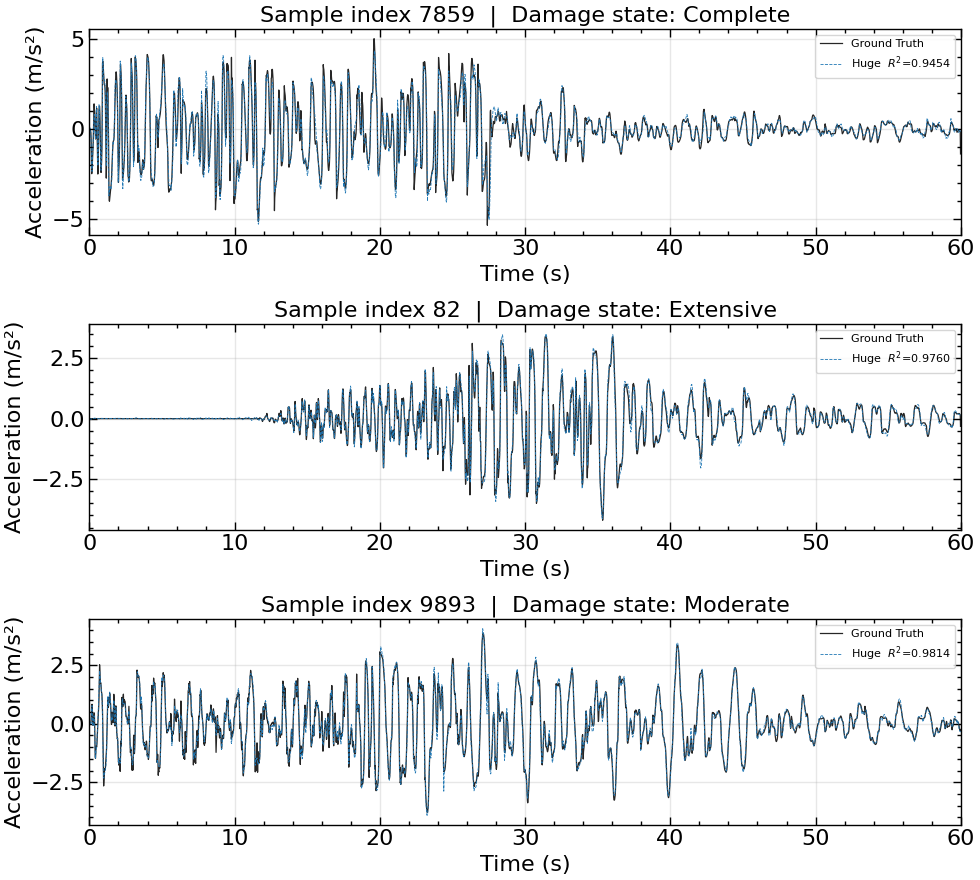

In [9]:
# ── Plot settings ─────────────────────────────────────────────────────────────
DT          = 0.02          # sampling interval (s)
TMAX        = 60.0          # x-axis limit (s); set None to use full signal
LINEWIDTH   = 0.6
SAVE_FIGS   = True          # save PDF to Fig_Paper_export/

DS_LABELS = {0: 'None', 1: 'Slight', 2: 'Moderate', 3: 'Extensive', 4: 'Complete'}
MODEL_LABEL = model_folder.name.split('-FNO')[0]   # short display name


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 0.0 if ss_tot == 0 else 1 - ss_res / ss_tot


fig_size = (10, 3 * len(results))
fig, axes = plt.subplots(len(results), 1, figsize=fig_size, squeeze=False)

for ax_row, res in zip(axes, results):
    ax = ax_row[0]
    n   = len(res['gt'])
    t   = np.arange(n) * DT
    r2  = r2_score(res['gt'], res['pred'])
    ds  = DS_LABELS.get(res['damage_state'], '?')

    ax.plot(t, res['gt'],   '-',  color='k',       lw=LINEWIDTH * 1.5, label='Ground Truth', alpha=0.85)
    ax.plot(t, res['pred'], '--', color='#1f77b4',  lw=LINEWIDTH,       label=f'{MODEL_LABEL}  $R^2$={r2:.4f}')

    if TMAX:
        ax.set_xlim(0, TMAX)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.set_title(f'Sample index {res["index"]}  |  Damage state: {ds}')
    ax.legend(fontsize=8, frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

if SAVE_FIGS:
    out = FIG_EXPORT_DIR / f'review_time_history_{MODEL_LABEL}.pdf'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'Saved → {out}')

plt.show()

### 4-b  Fourier Amplitude Spectrum

Saved → Fig_Paper_export\review_fft_amplitude_Huge.pdf


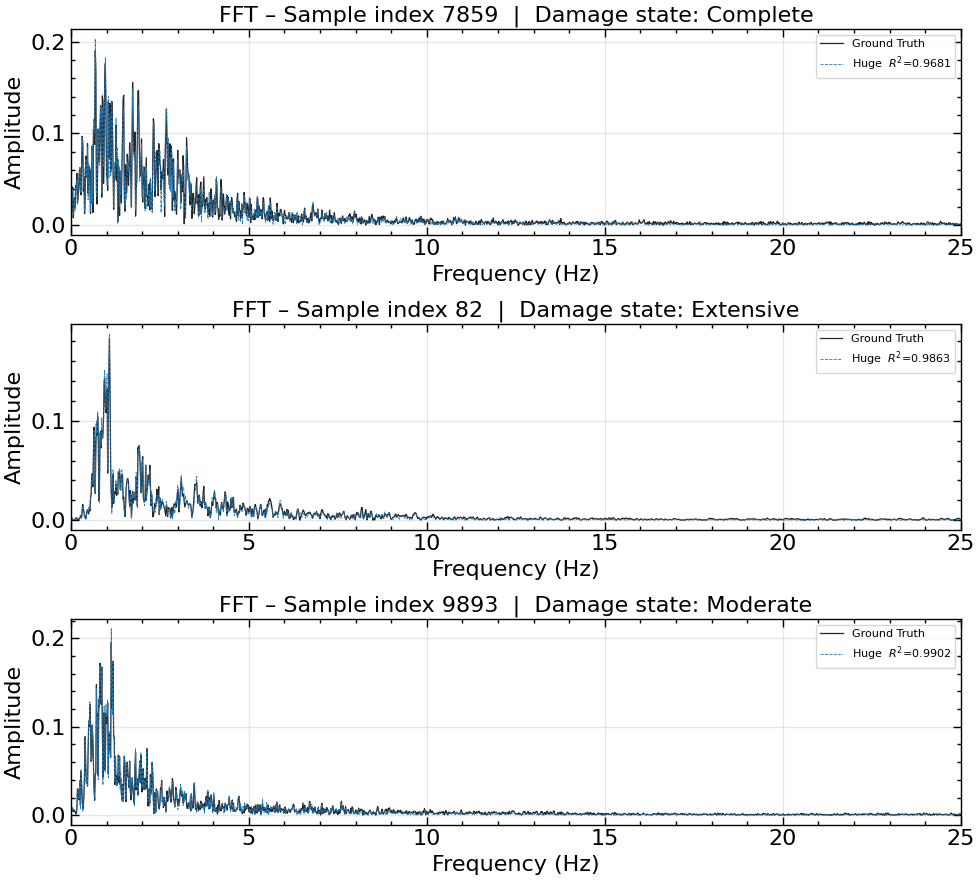

In [10]:
FFT_XLIM   = 25     # max frequency to display (Hz)
FFT_TYPE   = 'amplitude'   # 'amplitude' (linear y) or 'magnitude' (log y)

fig, axes = plt.subplots(len(results), 1, figsize=fig_size, squeeze=False)

for ax_row, res in zip(axes, results):
    ax  = ax_row[0]
    n   = len(res['gt'])
    t   = np.arange(n) * DT
    freq = np.fft.rfftfreq(n, d=DT)

    gt_fft   = np.abs(np.fft.rfft(res['gt']))   / n
    pred_fft = np.abs(np.fft.rfft(res['pred'])) / n
    spec_r2  = r2_score(gt_fft, pred_fft)

    plot_fn = ax.semilogy if FFT_TYPE == 'magnitude' else ax.plot

    plot_fn(freq, gt_fft,   '-',  color='k',      lw=LINEWIDTH * 1.5, label='Ground Truth', alpha=0.85)
    plot_fn(freq, pred_fft, '--', color='#1f77b4', lw=LINEWIDTH,       label=f'{MODEL_LABEL}  $R^2$={spec_r2:.4f}')

    ax.set_xlim(0, FFT_XLIM)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude' if FFT_TYPE == 'amplitude' else 'Magnitude')
    ds  = DS_LABELS.get(res['damage_state'], '?')
    ax.set_title(f'FFT – Sample index {res["index"]}  |  Damage state: {ds}')
    ax.legend(fontsize=8, frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

if SAVE_FIGS:
    out = FIG_EXPORT_DIR / f'review_fft_{FFT_TYPE}_{MODEL_LABEL}.pdf'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'Saved → {out}')

plt.show()

## 5 · Summary Table

In [11]:
import pandas as pd

rows = []
for res in results:
    n        = len(res['gt'])
    freq     = np.fft.rfftfreq(n, d=DT)
    gt_fft   = np.abs(np.fft.rfft(res['gt']))   / n
    pred_fft = np.abs(np.fft.rfft(res['pred'])) / n
    rows.append({
        'Sample Index'   : res['index'],
        'Damage State'   : DS_LABELS.get(res['damage_state'], '?'),
        'R² (time)'      : round(r2_score(res['gt'], res['pred']), 6),
        'R² (spectral)'  : round(r2_score(gt_fft, pred_fft), 6),
        'RMSE (time)'    : round(float(np.sqrt(np.mean((res['gt'] - res['pred'])**2))), 6),
    })

df = pd.DataFrame(rows)
df

,Sample Index,Damage State,R² (time),R² (spectral),RMSE (time)
0,7859,Complete,0.945382,0.968058,0.354739
1,82,Extensive,0.975968,0.986326,0.150350
2,9893,Moderate,0.981359,0.990158,0.161798


## 6 · Classical Ground Motions

Run the selected model on the four benchmark recordings stored in `test_sample/` and compare against the pre-computed roof-acceleration ground truth.

| File | Event |
|---|---|
| `1940-ElCentro-60s-50Hz-ms2.txt` | El Centro 1940 |
| `1971-Sanfernando-60s-50Hz-ms2.txt` | San Fernando 1971 |
| `1985-Michoacan-60s-200Hz-ms2.txt` | Michoacán 1985 |
| `1991-Kobe-60s-100Hz-ms2.txt` | Kobe 1991 |


In [12]:
from matplotlib.ticker import LogLocator, NullFormatter, FormatStrFormatter

TEST_SAMPLE_DIR = Path('test_sample')

# Input GM → Ground-Truth roof acceleration mapping
GM_TO_GT_MAP = {
    '1940-ElCentro-60s-50Hz-ms2.txt'    : 'Blg1_1940-ElCentro-60s-50Hz-ms2_RoofAcc.txt',
    '1971-Sanfernando-60s-50Hz-ms2.txt' : 'Blg1_1971-Sanfernando-60s-50Hz-ms2_RoofAcc.txt',
    '1985-Michoacan-60s-200Hz-ms2.txt'  : 'Blg1_1985-Michoacan-60s-200Hz-ms2_RoofAcc.txt',
    '1991-Kobe-60s-100Hz-ms2.txt'       : 'Blg1_1991-Kobe-60s-100Hz-ms2_RoofAcc.txt',
}

# Zoom windows for time-history panels [t_start, t_end] in seconds
ZOOM_INTERVALS = {
    '1940-ElCentro-60s-50Hz-ms2.txt'    : (0.0,  10.0),
    '1971-Sanfernando-60s-50Hz-ms2.txt' : (0.0,   6.0),
    '1985-Michoacan-60s-200Hz-ms2.txt'  : (8.0,  14.0),
    '1991-Kobe-60s-100Hz-ms2.txt'       : (2.0,  12.0),
}

# Display names
GM_TITLES = {
    '1940-ElCentro-60s-50Hz-ms2.txt'    : 'El Centro (1940)',
    '1971-Sanfernando-60s-50Hz-ms2.txt' : 'San Fernando (1971)',
    '1985-Michoacan-60s-200Hz-ms2.txt'  : 'Michoacán (1985)',
    '1991-Kobe-60s-100Hz-ms2.txt'       : 'Kobe (1991)',
}


def load_txt_data(file_path, target_hz=50, target_len=3000):
    """Load a two-column (time, value) text file, resample to target_hz, and
    truncate/pad to target_len samples."""
    with open(file_path, 'r') as f:
        lines = f.readlines()

    times, values = [], []
    for line in lines[1:]:          # skip header row
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                times.append(float(parts[0]))
                values.append(float(parts[1]))
            except ValueError:
                pass

    times  = np.array(times)
    values = np.array(values)

    if len(times) < 2:
        return np.zeros(target_len)

    dt         = times[1] - times[0]
    current_hz = round(1.0 / dt)
    step       = max(1, int(current_hz / target_hz))
    resampled  = values[::step]

    if len(resampled) > target_len:
        resampled = resampled[:target_len]
    elif len(resampled) < target_len:
        resampled = np.pad(resampled, (0, target_len - len(resampled)))

    return resampled


def infer_single(model, gm_array, device='cuda'):
    """Run model on a 1-D numpy GM array → numpy prediction array."""
    model.eval()
    with torch.no_grad():
        x    = torch.from_numpy(gm_array).float().unsqueeze(0).unsqueeze(0).to(device)
        pred = model(x).cpu().numpy().squeeze()
    return pred


In [13]:
# Load GM inputs, ground truths, and run inference
classical_results = []

for gm_file, gt_file in GM_TO_GT_MAP.items():
    gm_path = TEST_SAMPLE_DIR / gm_file
    gt_path = TEST_SAMPLE_DIR / gt_file

    if not gm_path.exists():
        print(f'[SKIP] GM file not found: {gm_path}')
        continue
    if not gt_path.exists():
        print(f'[SKIP] GT file not found: {gt_path}')
        continue

    gm_data = load_txt_data(gm_path)
    gt_data = load_txt_data(gt_path)
    pred    = infer_single(model, gm_data, device)

    classical_results.append({
        'filename' : gm_file,
        'title'    : GM_TITLES[gm_file],
        'gm'       : gm_data,
        'gt'       : gt_data,
        'pred'     : pred,
        'zoom'     : ZOOM_INTERVALS.get(gm_file),
    })
    print(f'OK  {GM_TITLES[gm_file]:30s}  R²={r2_score(gt_data, pred):.4f}')

print(f'\n{len(classical_results)} / {len(GM_TO_GT_MAP)} records loaded.')


OK  El Centro (1940)                R²=0.9824
OK  San Fernando (1971)             R²=0.7501
OK  Michoacán (1985)                R²=0.8966
OK  Kobe (1991)                     R²=0.9711

4 / 4 records loaded.


### 6-a  Time-history (main + zoomed panel)


Saved → Fig_Paper_export\classical_time_history_Huge.pdf


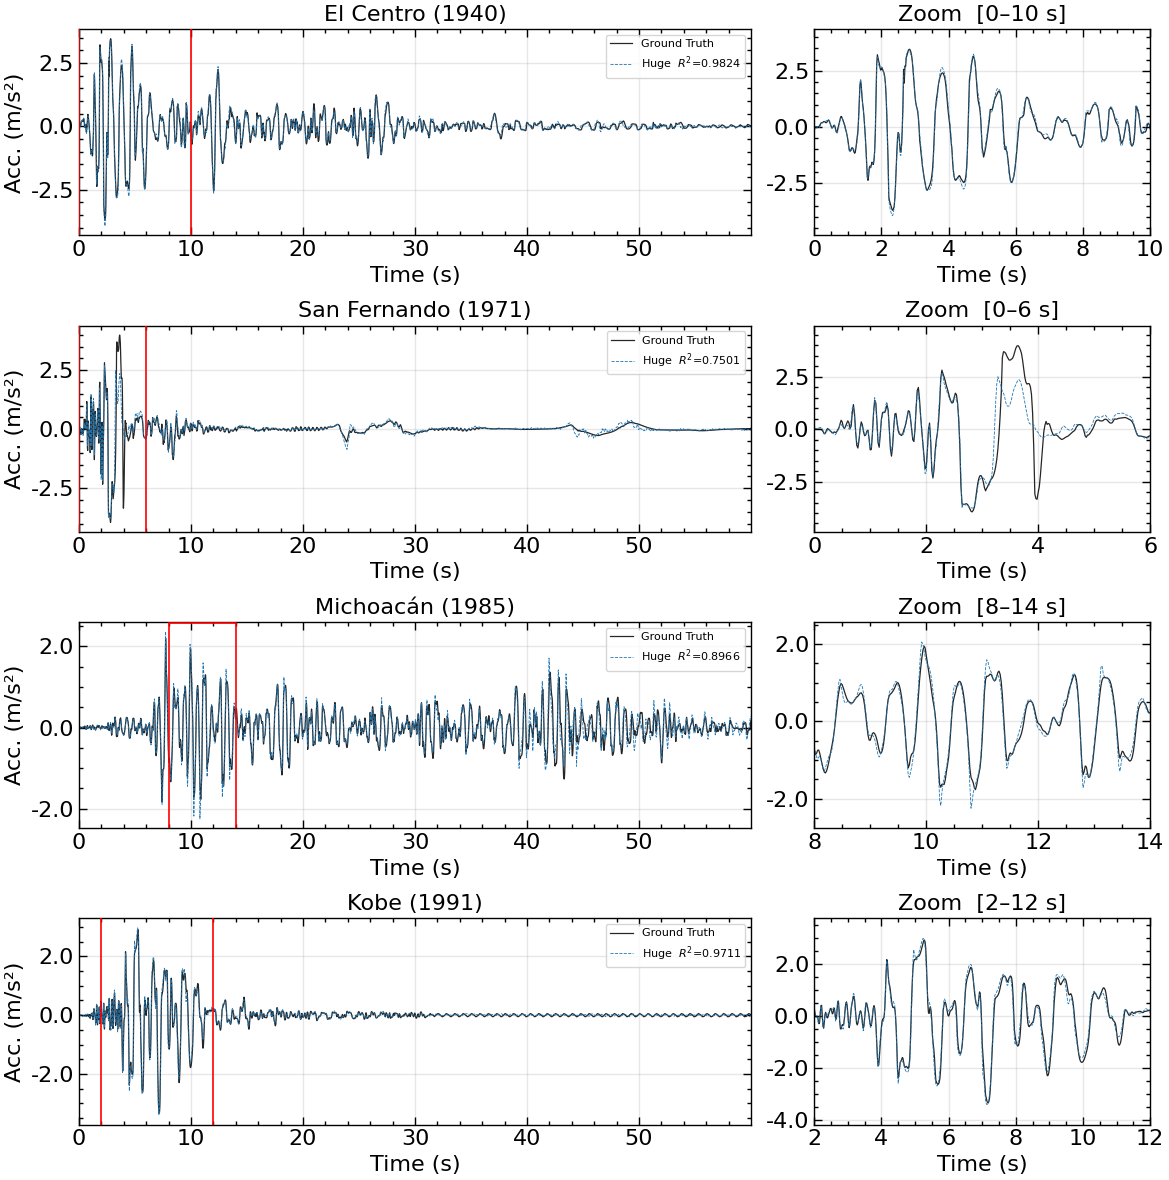

In [14]:
from matplotlib.patches import Rectangle

LW     = 0.6          # line width for classical GM plots
DT_GM  = 0.02         # 50 Hz → 0.02 s

n_gms   = len(classical_results)
fig_th, axes_th = plt.subplots(
    n_gms, 2, figsize=(12, 3.0 * n_gms),
    gridspec_kw={'width_ratios': [2, 1]},
)
if n_gms == 1:
    axes_th = axes_th[np.newaxis, :]   # keep 2-D indexing

for row, rec in enumerate(classical_results):
    t      = np.arange(len(rec['gt'])) * DT_GM
    ax     = axes_th[row, 0]
    ax_z   = axes_th[row, 1]
    r2_val = r2_score(rec['gt'], rec['pred'])

    ax.plot(t, rec['gt'],   '-',  color='k',      lw=LW * 1.5, label='Ground Truth', alpha=0.85)
    ax.plot(t, rec['pred'], '--', color='#1f77b4', lw=LW,
            label=f'{MODEL_LABEL}  $R^2$={r2_val:.4f}')

    ax.set_xlim(0, t[-1])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Acc. (m/s²)')
    ax.set_title(rec['title'])
    ax.legend(fontsize=8, frameon=True)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # ── Zoomed panel ──────────────────────────────────────────────────────────
    if rec['zoom']:
        t0, t1 = rec['zoom']
        mask   = (t >= t0) & (t <= t1)

        ax_z.plot(t[mask], rec['gt'][mask],   '-',  color='k',      lw=LW * 1.5, alpha=0.85)
        ax_z.plot(t[mask], rec['pred'][mask], '--', color='#1f77b4', lw=LW)
        ax_z.set_xlim(t0, t1)

        y_all  = np.concatenate([rec['gt'][mask], rec['pred'][mask]])
        y_min, y_max = y_all.min(), y_all.max()
        margin = (y_max - y_min) * 0.12 if y_max != y_min else 0.1
        ax_z.set_ylim(y_min - margin, y_max + margin)
        ax_z.set_title(f'Zoom  [{t0:.0f}–{t1:.0f} s]')
        ax_z.set_xlabel('Time (s)')
        ax_z.grid(True, alpha=0.3)
        ax_z.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # Red rectangle on main panel
        rect = Rectangle(
            (t0, y_min - margin), t1 - t0, (y_max + margin) - (y_min - margin),
            lw=1.2, edgecolor='red', facecolor='none', zorder=10
        )
        ax.add_patch(rect)
    else:
        ax_z.set_visible(False)

plt.tight_layout()

if SAVE_FIGS:
    out = FIG_EXPORT_DIR / f'classical_time_history_{MODEL_LABEL}.pdf'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'Saved → {out}')

plt.show()


### 6-b  Fourier Amplitude Spectrum (2 × 2, log-y)


Saved → Fig_Paper_export\classical_fft_Huge.pdf


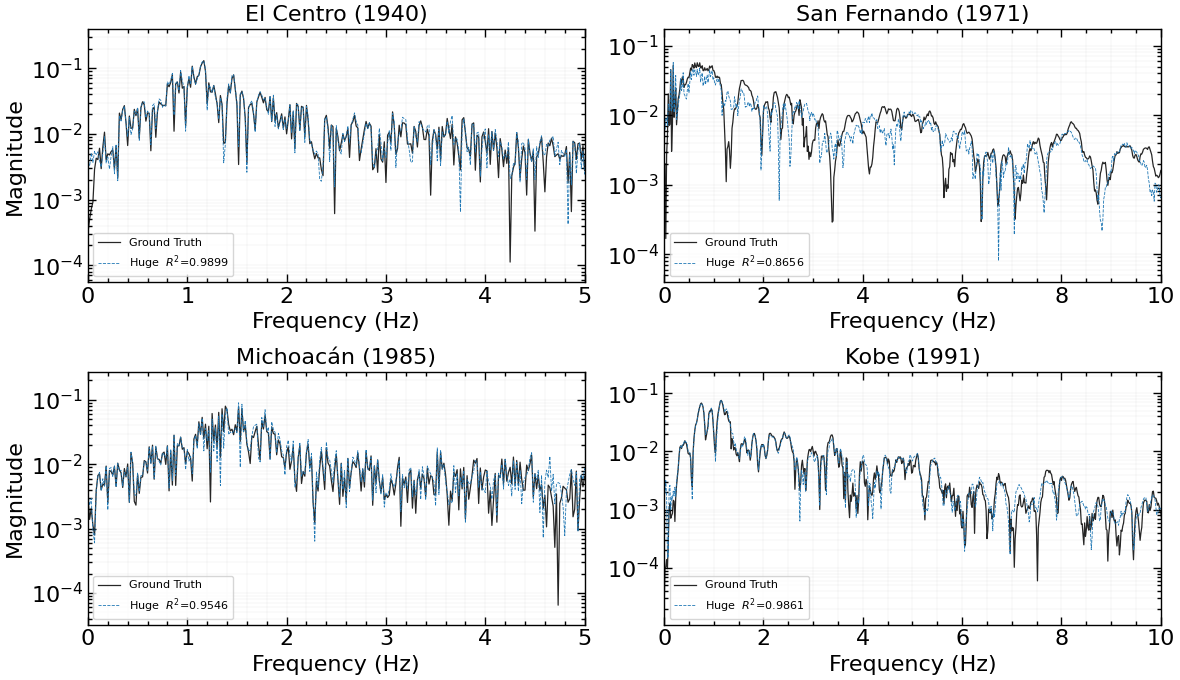

In [15]:
rows_fft, cols_fft = 2, 2
fig_fft, axes_fft = plt.subplots(rows_fft, cols_fft, figsize=(12, 7))
axes_flat = axes_fft.flatten()

# x-axis cap per event (Hz)
XLIM_MAP = {
    '1940-ElCentro-60s-50Hz-ms2.txt'    : 5,
    '1971-Sanfernando-60s-50Hz-ms2.txt' : 10,
    '1985-Michoacan-60s-200Hz-ms2.txt'  : 5,
    '1991-Kobe-60s-100Hz-ms2.txt'       : 10,
}

for idx, rec in enumerate(classical_results):
    ax  = axes_flat[idx]
    n   = len(rec['gt'])
    freq = np.fft.rfftfreq(n, d=DT_GM)

    gt_fft   = np.abs(np.fft.rfft(rec['gt']))   / n
    pred_fft = np.abs(np.fft.rfft(rec['pred'])) / n
    spec_r2  = r2_score(gt_fft, pred_fft)

    ax.semilogy(freq, gt_fft,   '-',  color='k',      lw=LW * 1.5, label='Ground Truth', alpha=0.85)
    ax.semilogy(freq, pred_fft, '--', color='#1f77b4', lw=LW,
                label=f'{MODEL_LABEL}  $R^2$={spec_r2:.4f}')

    xlim = XLIM_MAP.get(rec['filename'], 10)
    ax.set_xlim(0, xlim)

    # Auto y-range on visible data
    mask_f     = freq <= xlim
    vis        = np.concatenate([gt_fft[mask_f], pred_fft[mask_f]])
    vis_pos    = vis[vis > 1e-9]
    if len(vis_pos):
        ax.set_ylim(vis_pos.min() * 0.5, vis_pos.max() * 3)

    # Log-scale minor ticks
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=8))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 1.0, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.set_title(rec['title'])
    ax.set_xlabel('Frequency (Hz)')
    if idx % cols_fft == 0:
        ax.set_ylabel('Magnitude')
    ax.grid(True, which='both', alpha=0.3, lw=0.3)
    ax.legend(fontsize=8, frameon=True, loc='lower left')

# hide unused panel if fewer than 4 records
for extra in range(len(classical_results), rows_fft * cols_fft):
    axes_flat[extra].set_visible(False)

fig_fft.align_ylabels(axes_fft[:, 0])
plt.tight_layout()

if SAVE_FIGS:
    out = FIG_EXPORT_DIR / f'classical_fft_{MODEL_LABEL}.pdf'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'Saved → {out}')

plt.show()


In [16]:
# Classical GM metrics summary
import pandas as pd   # already imported above, safe to re-import

crows = []
for rec in classical_results:
    n         = len(rec['gt'])
    freq_c    = np.fft.rfftfreq(n, d=DT_GM)
    gt_f      = np.abs(np.fft.rfft(rec['gt']))   / n
    pred_f    = np.abs(np.fft.rfft(rec['pred'])) / n
    crows.append({
        'Event'          : rec['title'],
        'R² (time)'      : round(r2_score(rec['gt'], rec['pred']), 6),
        'R² (spectral)'  : round(r2_score(gt_f, pred_f), 6),
        'RMSE (time)'    : round(float(np.sqrt(np.mean((rec['gt'] - rec['pred'])**2))), 6),
        'Peak GT (m/s²)' : round(float(np.max(np.abs(rec['gt']))), 4),
        'Peak Pred (m/s²)': round(float(np.max(np.abs(rec['pred']))), 4),
    })

pd.DataFrame(crows)


,Event,R² (time),R² (spectral),RMSE (time),Peak GT (m/s²),Peak Pred (m/s²)
0,El Centro (1940),0.982364,0.989866,0.089053,3.7095,3.9397
1,San Fernando (1971),0.750076,0.865567,0.264759,3.9845,3.7673
2,Michoacán (1985),0.896576,0.954580,0.145121,2.1974,2.3648
3,Kobe (1991),0.971145,0.986088,0.082369,3.3335,3.3988
